======= Machine Maintenance Prediction using ARIMA =======
Please upload your machine data CSV file


Saving data (1).csv to data (1) (1).csv

Dataset Preview:
   footfall  tempMode  AQ  USS  CS  VOC  RP  IP  Temperature  fail
0         0         7   7    1   6    6  36   3            1     1
1       190         1   3    3   5    1  20   4            1     0
2        31         7   2    2   6    1  24   6            1     0
3        83         4   3    4   5    1  28   6            1     0
4       640         7   5    6   4    0  68   6            1     0

Dataset Columns: ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']

No timestamp column found. Creating a sequence timestamp.
Dataset indexed by timestamp.

Do you want to optimize ARIMA parameters? (y/n, may take time): y

Optimizing ARIMA parameters (this may take a while)...
New best AIC: 15874.791641675014 with order (0, 0, 1)
New best AIC: 15864.30581834694 with order (0, 1, 1)
Progress: 5/32 combinations tested
Progress: 10/32 combinations tested
Progress: 15/32 combinations tested
Progress: 

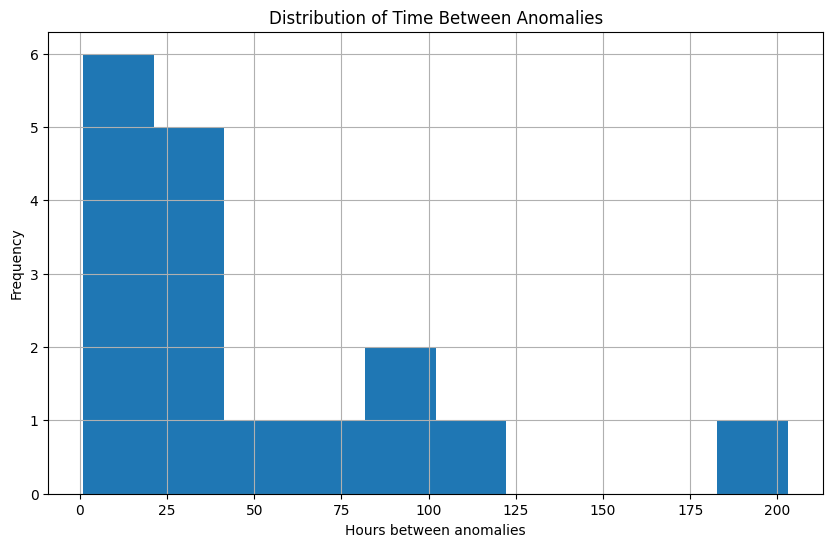


How many periods ahead would you like to forecast? 3

Predicting future values for 3 periods ahead...


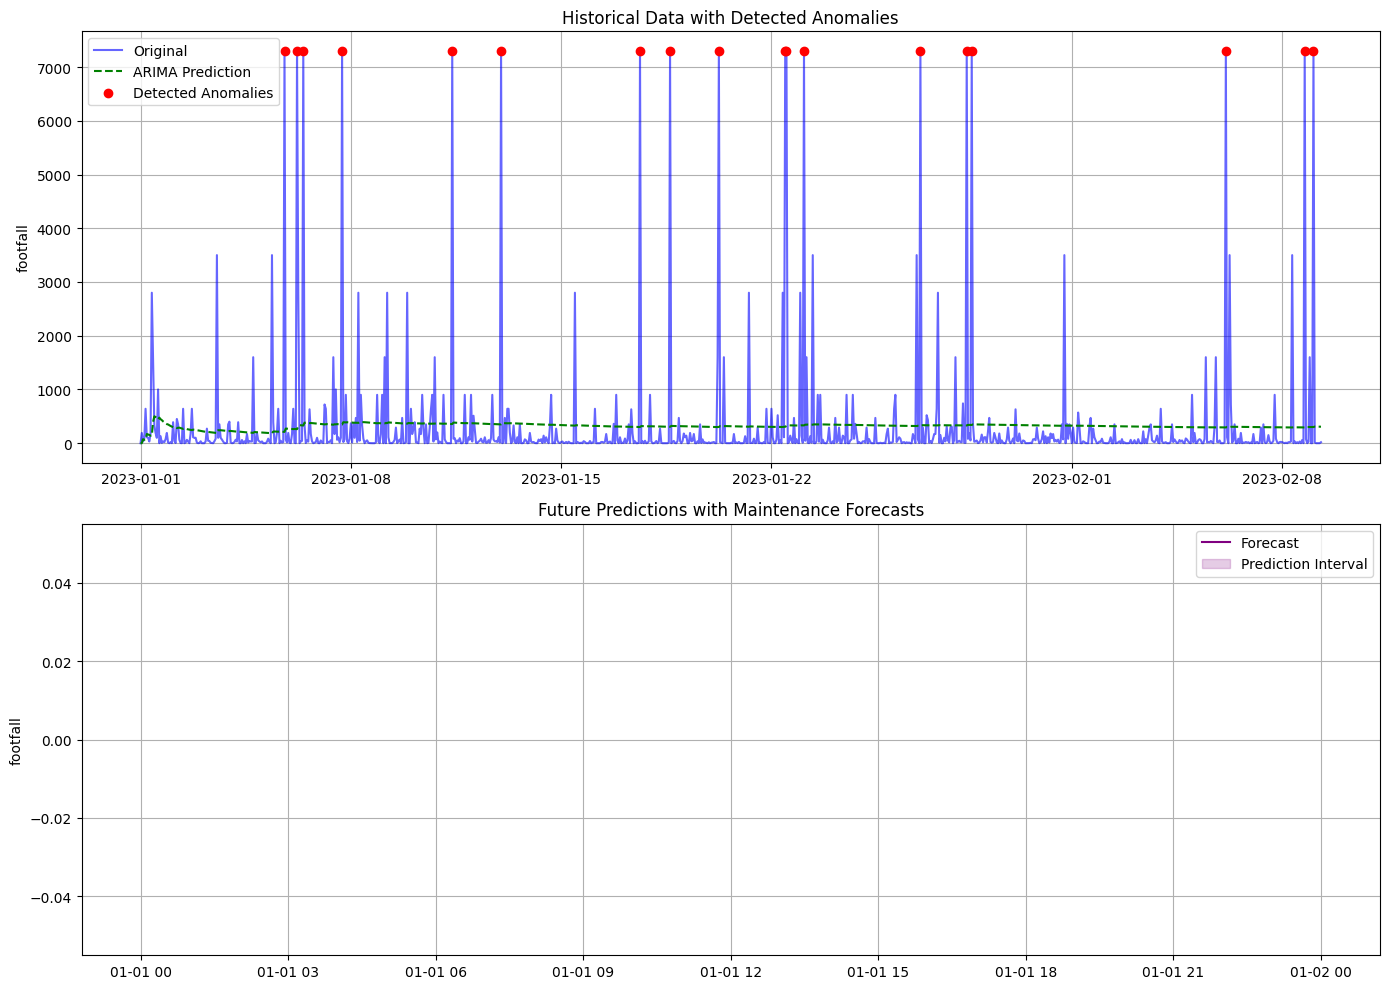

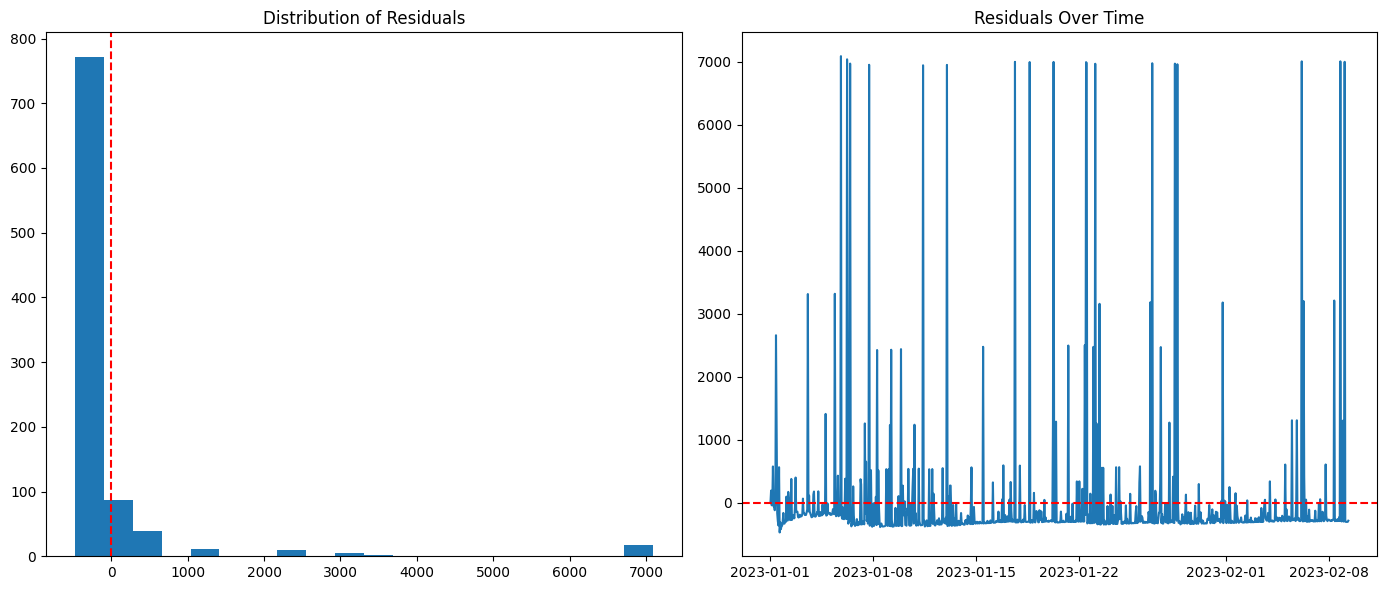

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Results saved to CSV files and downloaded.

======= Analysis Complete =======

Maintenance Prediction Summary:
No definite maintenance points predicted within forecast horizon.

Recommendations:
1. Schedule preventive maintenance before predicted failure points
2. Monitor system more closely near possible maintenance points
3. Consider a comprehensive analysis with additional metrics


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from datetime import datetime, timedelta
from google.colab import files
import io
import warnings
warnings.filterwarnings('ignore')

def load_data():
    """Load and prepare data from uploaded file"""
    print("Please upload your machine data CSV file")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]

    # Read the uploaded CSV
    df = pd.read_csv(io.BytesIO(uploaded[filename]))

    # Display basic information
    print("\nDataset Preview:")
    print(df.head())
    print("\nDataset Columns:", df.columns.tolist())

    # Check if dataset has timestamp column
    date_columns = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]

    if date_columns:
        timestamp_col = date_columns[0]
        print(f"\nFound timestamp column: {timestamp_col}")
    else:
        print("\nNo timestamp column found. Creating a sequence timestamp.")
        timestamp_col = 'timestamp'
        df[timestamp_col] = pd.date_range(start='2023-01-01', periods=len(df), freq='H')

    # Ensure timestamp column is datetime
    if timestamp_col in df.columns:
        try:
            df[timestamp_col] = pd.to_datetime(df[timestamp_col])
            df = df.set_index(timestamp_col)
            print("Dataset indexed by timestamp.")
        except:
            print("Couldn't convert timestamp column to datetime.")

    # Check if 'footfall' column exists, if not let user select a column
    if 'footfall' not in df.columns:
        print("\nThe 'footfall' column was not found in the dataset.")
        print("Available columns:", df.columns.tolist())
        target_column = input("Please enter the name of the column to analyze: ")
    else:
        target_column = 'footfall'

    return df, target_column

def detect_anomalies(df, target_column, order=(2,1,2), threshold_factor=3):
    """
    Detect anomalies using ARIMA model

    Args:
        df: DataFrame with time series data
        target_column: Column to analyze
        order: ARIMA model order (p,d,q)
        threshold_factor: Number of std deviations for anomaly threshold

    Returns:
        DataFrame with anomaly detection results
    """
    print(f"\nDetecting anomalies in '{target_column}' using ARIMA{order}...")

    # Extract series
    series = df[target_column]

    # Train ARIMA model
    model = ARIMA(series, order=order)
    model_fit = model.fit()

    # Predict values - start at the beginning of the series
    predictions = model_fit.predict(start=0, end=len(series)-1)

    # Compute residuals - ensure they have the same shape
    residuals = series.values - predictions.values

    # Calculate threshold for anomaly detection
    threshold = np.mean(np.abs(residuals)) + threshold_factor * np.std(np.abs(residuals))

    # Create results DataFrame
    df_result = df.copy()
    df_result['prediction'] = predictions
    df_result['residual'] = residuals
    df_result['anomaly'] = np.where(np.abs(residuals) > threshold, 1, 0)

    # Count anomalies
    anomaly_count = df_result['anomaly'].sum()
    print(f"Detected {anomaly_count} anomalies out of {len(residuals)} points")

    return df_result, model_fit

def analyze_anomaly_patterns(df_result):
    """Analyze patterns in detected anomalies"""
    # Check if there are any anomalies
    if df_result['anomaly'].sum() == 0:
        print("No anomalies detected to analyze.")
        return None, None

    # Get anomaly points
    anomaly_points = df_result[df_result['anomaly'] == 1]

    # Calculate time gaps between anomalies
    if len(anomaly_points) > 1 and isinstance(anomaly_points.index, pd.DatetimeIndex):
        time_diffs = anomaly_points.index[1:] - anomaly_points.index[:-1]
        avg_time_between_anomalies = time_diffs.mean()
        std_time_between_anomalies = time_diffs.std()

        print(f"\nAverage time between anomalies: {avg_time_between_anomalies}")
        print(f"Standard deviation: {std_time_between_anomalies}")

        # Plot distribution of time between anomalies
        plt.figure(figsize=(10, 6))
        plt.hist([td.total_seconds()/3600 for td in time_diffs], bins=10)
        plt.xlabel('Hours between anomalies')
        plt.ylabel('Frequency')
        plt.title('Distribution of Time Between Anomalies')
        plt.grid(True)
        plt.show()

        return avg_time_between_anomalies, std_time_between_anomalies
    elif len(anomaly_points) > 1:
        # For non-datetime indices
        indices = anomaly_points.index.tolist()
        gaps = [indices[i+1] - indices[i] for i in range(len(indices)-1)]
        avg_gap = sum(gaps) / len(gaps)
        std_gap = np.std(gaps)

        print(f"\nAverage gap between anomalies: {avg_gap} data points")
        print(f"Standard deviation: {std_gap} data points")

        # Plot distribution of gaps
        plt.figure(figsize=(10, 6))
        plt.hist(gaps, bins=10)
        plt.xlabel('Data points between anomalies')
        plt.ylabel('Frequency')
        plt.title('Distribution of Gaps Between Anomalies')
        plt.grid(True)
        plt.show()

        return avg_gap, std_gap
    else:
        print("Not enough anomalies to analyze patterns.")
        return None, None

def predict_future_maintenance(df_result, model_fit, target_column, periods=30, threshold_factor=3):
    """
    Predict future values and potential maintenance needs

    Args:
        df_result: DataFrame with anomaly detection results
        model_fit: Fitted ARIMA model
        target_column: Target column name
        periods: Number of periods to forecast
        threshold_factor: Number of std deviations for anomaly threshold

    Returns:
        DataFrame with future predictions and maintenance forecasts
    """
    print(f"\nPredicting future values for {periods} periods ahead...")

    # Get last date/index in the dataset
    last_date = df_result.index[-1] if isinstance(df_result.index, pd.DatetimeIndex) else df_result.index[-1]

    # Generate future dates if using datetime index
    if isinstance(df_result.index, pd.DatetimeIndex):
        # Determine frequency of data
        try:
            freq = pd.infer_freq(df_result.index)
            if freq is None:
                # Default to daily if can't determine
                freq = 'D'
        except:
            freq = 'D'

        future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=periods, freq=freq)
        future_df = pd.DataFrame(index=future_dates, columns=[target_column])
    else:
        # Use numeric index
        future_indices = range(df_result.index[-1] + 1, df_result.index[-1] + periods + 1)
        future_df = pd.DataFrame(index=future_indices, columns=[target_column])

    # Forecast future values
    forecast = model_fit.forecast(steps=periods)
    future_df[target_column] = forecast

    # Calculate prediction intervals (approximation)
    std_residuals = np.std(df_result['residual'])
    future_df['lower_bound'] = forecast - 2 * std_residuals
    future_df['upper_bound'] = forecast + 2 * std_residuals

    # Use historical anomaly patterns to predict maintenance
    anomaly_points = df_result[df_result['anomaly'] == 1]

    if len(anomaly_points) > 1:
        if isinstance(df_result.index, pd.DatetimeIndex):
            # Calculate average time between anomalies
            time_diffs = anomaly_points.index[1:] - anomaly_points.index[:-1]
            avg_time_between_anomalies = time_diffs.mean()

            # Predict next anomaly
            last_anomaly_date = anomaly_points.index[-1]
            next_predicted_anomaly = last_anomaly_date + avg_time_between_anomalies

            # Flag in forecast if within prediction horizon
            future_df['maintenance_needed'] = 0
            for i, date in enumerate(future_df.index):
                if date >= next_predicted_anomaly:
                    future_df.loc[date, 'maintenance_needed'] = 1
                    print(f"Maintenance predicted on {date}")
                    # Predict subsequent maintenance times
                    next_maintenance_date = date + avg_time_between_anomalies
                    while next_maintenance_date in future_df.index:
                        future_df.loc[next_maintenance_date, 'maintenance_needed'] = 1
                        print(f"Subsequent maintenance predicted on {next_maintenance_date}")
                        next_maintenance_date += avg_time_between_anomalies
                    break
        else:
            # For non-datetime indices
            indices = anomaly_points.index.tolist()
            gaps = [indices[i+1] - indices[i] for i in range(len(indices)-1)]
            avg_gap = sum(gaps) / len(gaps)

            # Predict next anomaly
            last_anomaly_idx = anomaly_points.index[-1]
            next_predicted_anomaly = last_anomaly_idx + int(avg_gap)

            # Flag in forecast if within prediction horizon
            future_df['maintenance_needed'] = 0
            for idx in future_df.index:
                if idx >= next_predicted_anomaly:
                    future_df.loc[idx, 'maintenance_needed'] = 1
                    print(f"Maintenance predicted at data point {idx}")
                    # Predict subsequent maintenance times
                    next_maintenance_idx = idx + int(avg_gap)
                    while next_maintenance_idx in future_df.index:
                        future_df.loc[next_maintenance_idx, 'maintenance_needed'] = 1
                        print(f"Subsequent maintenance predicted at data point {next_maintenance_idx}")
                        next_maintenance_idx += int(avg_gap)
                    break

    # Use deviation from forecast to predict potential new anomalies
    # This complements the pattern-based approach
    residual_threshold = np.mean(np.abs(df_result['residual'])) + threshold_factor * np.std(np.abs(df_result['residual']))

    # Identify points with high prediction interval uncertainty
    uncertain_points = future_df.index[(future_df['upper_bound'] - future_df['lower_bound']) > 2 * residual_threshold]

    if len(uncertain_points) > 0:
        for point in uncertain_points:
            if future_df.loc[point, 'maintenance_needed'] == 0:
                future_df.loc[point, 'maintenance_needed'] = 0.5  # Mark as "possible" maintenance needed
                print(f"Possible maintenance needed at {point} due to high uncertainty")

    return future_df

def visualize_results(df_result, future_df, target_column):
    """Visualize anomaly detection and future predictions"""
    # Create figure with 2 subplots
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

    # Plot 1: Historical data with anomalies
    ax1 = axes[0]

    # Plot original series
    ax1.plot(df_result[target_column], label='Original', color='blue', alpha=0.6)

    # Plot predictions
    if 'prediction' in df_result.columns:
        ax1.plot(df_result['prediction'], label='ARIMA Prediction', color='green', linestyle='--')

    # Highlight anomalies
    anomaly_points = df_result[df_result['anomaly'] == 1]
    ax1.scatter(anomaly_points.index, anomaly_points[target_column],
               color='red', label='Detected Anomalies', zorder=5)

    ax1.set_title('Historical Data with Detected Anomalies')
    ax1.set_ylabel(target_column)
    ax1.legend()
    ax1.grid(True)

    # Plot 2: Future predictions with maintenance forecasts
    ax2 = axes[1]

    # Plot forecasted values
    ax2.plot(future_df[target_column], label='Forecast', color='purple')

    # Plot prediction intervals
    if 'lower_bound' in future_df.columns and 'upper_bound' in future_df.columns:
        ax2.fill_between(future_df.index,
                         future_df['lower_bound'],
                         future_df['upper_bound'],
                         color='purple', alpha=0.2, label='Prediction Interval')

    # Highlight predicted maintenance points
    if 'maintenance_needed' in future_df.columns:
        maintenance_points = future_df[future_df['maintenance_needed'] == 1]
        possible_points = future_df[future_df['maintenance_needed'] == 0.5]

        if not maintenance_points.empty:
            ax2.scatter(maintenance_points.index, maintenance_points[target_column],
                       color='red', marker='X', s=100, label='Predicted Maintenance', zorder=5)

            # Add vertical lines at maintenance points
            for idx in maintenance_points.index:
                ax2.axvline(x=idx, color='red', linestyle='--', alpha=0.5)

        if not possible_points.empty:
            ax2.scatter(possible_points.index, possible_points[target_column],
                       color='orange', marker='o', s=80, label='Possible Maintenance', zorder=4)

    ax2.set_title('Future Predictions with Maintenance Forecasts')
    ax2.set_ylabel(target_column)
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Additional plot: Residuals analysis
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.hist(df_result['residual'], bins=20)
    plt.title('Distribution of Residuals')
    plt.axvline(x=0, color='red', linestyle='--')

    plt.subplot(1, 2, 2)
    plt.plot(df_result['residual'])
    plt.title('Residuals Over Time')
    plt.axhline(y=0, color='red', linestyle='--')
    plt.tight_layout()
    plt.show()

def optimize_arima_parameters(series):
    """Find optimal ARIMA parameters using AIC"""
    best_aic = float('inf')
    best_order = None
    p_range = range(0, 4)
    d_range = range(0, 2)
    q_range = range(0, 4)

    print("\nOptimizing ARIMA parameters (this may take a while)...")
    progress_count = 0
    total_combinations = len(p_range) * len(d_range) * len(q_range)

    for p in p_range:
        for d in d_range:
            for q in q_range:
                if p == 0 and q == 0:
                    continue  # Skip invalid ARIMA(0,d,0) models

                try:
                    model = ARIMA(series, order=(p, d, q))
                    results = model.fit()
                    aic = results.aic

                    if aic < best_aic:
                        best_aic = aic
                        best_order = (p, d, q)
                        print(f"New best AIC: {best_aic} with order {best_order}")
                except:
                    continue

                progress_count += 1
                if progress_count % 5 == 0:
                    print(f"Progress: {progress_count}/{total_combinations} combinations tested")

    print(f"\nBest ARIMA order: {best_order} with AIC: {best_aic}")
    return best_order

def save_results(df_result, future_df):
    """Save results to CSV files"""
    # Save historical results with anomalies
    df_result.to_csv('anomaly_detection_results.csv')
    files.download('anomaly_detection_results.csv')

    # Save future predictions
    future_df.to_csv('maintenance_predictions.csv')
    files.download('maintenance_predictions.csv')

    print("\nResults saved to CSV files and downloaded.")

def main():
    print("======= Machine Maintenance Prediction using ARIMA =======")

    # Load data
    df, target_column = load_data()

    # Option to optimize ARIMA parameters
    optimize = input("\nDo you want to optimize ARIMA parameters? (y/n, may take time): ")
    if optimize.lower() == 'y':
        best_order = optimize_arima_parameters(df[target_column])
    else:
        best_order = (2, 1, 2)  # Default parameters

    # Detect anomalies
    df_result, model_fit = detect_anomalies(df, target_column, order=best_order)

    # Analyze anomaly patterns
    analyze_anomaly_patterns(df_result)

    # Predict future maintenance
    forecast_periods = int(input("\nHow many periods ahead would you like to forecast? "))
    future_df = predict_future_maintenance(df_result, model_fit, target_column, periods=forecast_periods)

    # Visualize results
    visualize_results(df_result, future_df, target_column)

    # Save results
    save_results(df_result, future_df)

    print("\n======= Analysis Complete =======")
    print("\nMaintenance Prediction Summary:")
    if 'maintenance_needed' in future_df.columns:
        maintenance_points = future_df[future_df['maintenance_needed'] == 1]
        possible_points = future_df[future_df['maintenance_needed'] == 0.5]

        if not maintenance_points.empty:
            print(f"\n{len(maintenance_points)} scheduled maintenance points predicted:")
            for idx in maintenance_points.index:
                print(f"  - Maintenance recommended at {idx}")
        else:
            print("No definite maintenance points predicted within forecast horizon.")

        if not possible_points.empty:
            print(f"\n{len(possible_points)} possible maintenance points identified:")
            for idx in possible_points.index:
                print(f"  - Possible maintenance needed at {idx}")

    print("\nRecommendations:")
    print("1. Schedule preventive maintenance before predicted failure points")
    print("2. Monitor system more closely near possible maintenance points")
    print("3. Consider a comprehensive analysis with additional metrics")

if __name__ == "__main__":
    main()